In [2]:
from common.paths import get_sber_gitignore_data_dpath, get_sber_data_dpath
from common.logger import JUPYTER_LOGGER as logger

import pandas as pd

import catboost
import lightgbm
import xgboost
from umap import UMAP
import optuna

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
features_fpath = get_sber_gitignore_data_dpath() / "features_with_judge_scores.csv"
test_fpath = get_sber_data_dpath() / "knowledge_bench_public.csv"
features_df = pd.read_csv(features_fpath)
test_df = pd.read_csv(test_fpath)
features_df.shape

(462, 1623)

In [4]:
print(test_df.shape)
test_df.head()

(1044, 5)


,prompt,model_answer,is_hallucination,correct_answer,comment
0,За что Оскар Густав Рейландер был удостоен мед...,Оскар Густав Рейландер был удостоен медали на ...,False,За выставленные фотографии,NaN
1,В каком году рэпер King Von был убит?,Рэпер King Von был убит 6 ноября 2020 года в А...,False,2020,NaN
2,Сколько миллионов рублей было выделено на реал...,На реализацию программы защиты свидетелей в Ро...,True,1318,NaN
3,Какая компания лицензировала на русском языке ...,"Компания ""Кино без границ"" лицензировала на ру...",True,Reanimedia,NaN
4,Кто из британских ревизионистов в 2000 году пр...,В 2000 году британский ревизионист Дэвид Ирвин...,True,Джоэла Хейворда,NaN


In [5]:
import warnings
warnings.filterwarnings("ignore")

target_col = "judge_score"

hooks_columns = [col for col in features_df.columns if col.startswith("feature_")]
other_num_columns = features_df.select_dtypes(include=["number"]).columns.difference(hooks_columns)
str_columns = features_df.select_dtypes(include=["object"]).columns.difference([target_col])

other_num_columns = other_num_columns.difference(["sample_id", "is_hallucination"])

logger.info(f"Кол-во признаков-хуков: {len(hooks_columns)}")
logger.info(f"Кол-во числовых признаков: {len(other_num_columns)}")
logger.info(f"Кол-во строковых признаков: {len(str_columns)}")

print(other_num_columns)
print(str_columns)

2026-03-31 13:09:47,165 - jupyter-notebooks - INFO - [JUPYTER 📓] Кол-во признаков-хуков: 1613
2026-03-31 13:09:47,167 - jupyter-notebooks - INFO - [JUPYTER 📓] Кол-во числовых признаков: 2
2026-03-31 13:09:47,168 - jupyter-notebooks - INFO - [JUPYTER 📓] Кол-во строковых признаков: 3


Index(['hallucination_score', 'temperature'], dtype='str')
Index(['ground_truth', 'model_answer', 'query'], dtype='str')


In [6]:
# basic str stats

#features_df["query_length"] = features_df["query"].str.len()
features_df["model_answer_length"] = features_df["model_answer"].str.len()
features_df["ground_truth_length"] = features_df["ground_truth"].str.len()

features_df["answer_gt_ratio"] = features_df["model_answer_length"] / (features_df["ground_truth_length"] + 1e-5)

other_num_columns = other_num_columns.union({"answer_gt_ratio"})

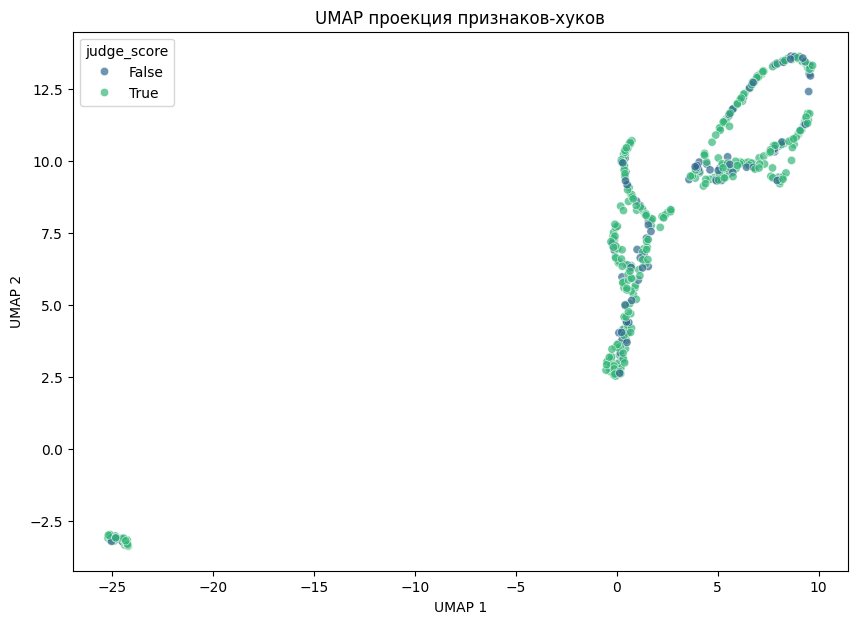

In [7]:
graphic_pca = UMAP(n_components=2, random_state=42)
points = graphic_pca.fit_transform(features_df[hooks_columns])

plt.figure(figsize=(10, 7))
sns.scatterplot(x=points[:, 0], y=points[:, 1], hue=features_df[target_col], palette="viridis", alpha=0.7)
plt.title("UMAP проекция признаков-хуков")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title=target_col)
plt.show()

In [8]:
n_components = 8

train_pca = PCA(n_components=n_components, random_state=42)

training_points = train_pca.fit_transform(features_df[hooks_columns])
pca_columns = [f"pca_{i}" for i in range(n_components)]
features_df[pca_columns] = training_points

2026-03-31 13:09:57,609 - jupyter-notebooks - INFO - [JUPYTER 📓] X columns: ['answer_gt_ratio', 'hallucination_score', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'temperature']



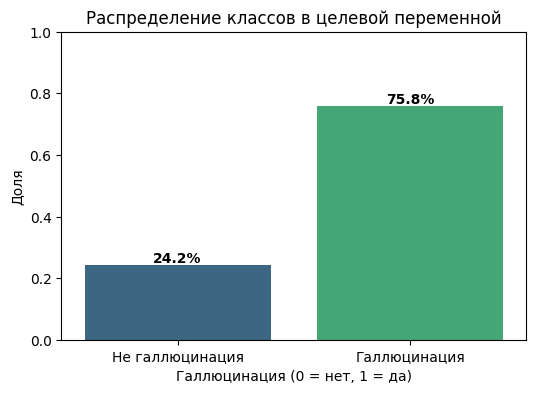

In [9]:
features_df[target_col] = features_df[target_col].fillna(features_df[target_col].mode()[0])
target = features_df[target_col].astype(int)

scaler = StandardScaler()
train_columns = other_num_columns.union(set(pca_columns))
features_df[train_columns] = scaler.fit_transform(features_df[train_columns])

X = features_df[train_columns]
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logger.info(
    f"X columns: {X.columns.tolist()}\n"
)

target_dist = y.value_counts(normalize=True)
plt.figure(figsize=(6, 4))
sns.barplot(x=target_dist.index, y=target_dist.values, palette="viridis")
plt.title("Распределение классов в целевой переменной")
plt.xlabel("Галлюцинация (0 = нет, 1 = да)")
plt.ylabel("Доля")
plt.xticks([0, 1], ["Не галлюцинация", "Галлюцинация"])
plt.ylim(0, 1)
for i, v in enumerate(target_dist.values[::-1]):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
plt.show()

In [10]:
def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["catboost", "lightgbm", "xgboost"])

    if model_type == "catboost":
        params = {
            "iterations": trial.suggest_int("iterations", 100, 1000),
            "depth": trial.suggest_int("depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
            "random_seed": 42,
            "verbose": False,
        }
        model = catboost.CatBoostClassifier(**params)

    elif model_type == "lightgbm":
        params = {
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "random_state": 42,
        }
        model = lightgbm.LGBMClassifier(**params, verbose=-1)

    else:  # xgboost
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "random_state": 42,
        }
        model = xgboost.XGBClassifier(**params)

    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

In [11]:
study = optuna.create_study(direction="maximize", study_name="model_selection")
study.optimize(objective, n_trials=50)

[I 2026-03-31 13:09:57,745] A new study created in memory with name: model_selection
[I 2026-03-31 13:09:57,846] Trial 0 finished with value: 0.7526881720430108 and parameters: {'model_type': 'xgboost', 'max_depth': 10, 'learning_rate': 0.0007209315651133824, 'n_estimators': 156}. Best is trial 0 with value: 0.7526881720430108.
[I 2026-03-31 13:10:00,782] Trial 1 finished with value: 0.9139784946236559 and parameters: {'model_type': 'lightgbm', 'num_leaves': 30, 'learning_rate': 0.018143745735782604, 'n_estimators': 531}. Best is trial 1 with value: 0.9139784946236559.
[I 2026-03-31 13:10:02,140] Trial 2 finished with value: 0.9247311827956989 and parameters: {'model_type': 'catboost', 'iterations': 402, 'depth': 8, 'learning_rate': 0.00011619883272714284}. Best is trial 2 with value: 0.9247311827956989.
[I 2026-03-31 13:10:02,336] Trial 3 finished with value: 0.9032258064516129 and parameters: {'model_type': 'xgboost', 'max_depth': 6, 'learning_rate': 0.030060634079879217, 'n_estimato

In [12]:
# best catboost trial
catboost_trials = [t for t in study.trials if t.params.get("model_type") == "catboost"]
best_catboost_trial = max(catboost_trials, key=lambda t: t.value)
best_trial = best_catboost_trial
logger.info(f"Лучший результат: {best_trial.value:.4f}")
logger.info("Лучшие параметры:")
for key, value in best_trial.params.items():
    logger.info(f"  {key}: {value}")

2026-03-31 13:11:22,506 - jupyter-notebooks - INFO - [JUPYTER 📓] Лучший результат: 0.9247
2026-03-31 13:11:22,506 - jupyter-notebooks - INFO - [JUPYTER 📓] Лучшие параметры:
2026-03-31 13:11:22,506 - jupyter-notebooks - INFO - [JUPYTER 📓]   model_type: catboost
2026-03-31 13:11:22,506 - jupyter-notebooks - INFO - [JUPYTER 📓]   iterations: 402
2026-03-31 13:11:22,515 - jupyter-notebooks - INFO - [JUPYTER 📓]   depth: 8
2026-03-31 13:11:22,515 - jupyter-notebooks - INFO - [JUPYTER 📓]   learning_rate: 0.00011619883272714284


In [13]:
def catboost_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        "random_seed": 42,
        "verbose": False,
    }
    model = catboost.CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    return model.score(X_test, y_test)

catboost_study = optuna.create_study(direction="maximize", study_name="catboost_tuning")
catboost_study.optimize(catboost_objective, n_trials=30)

best_catboost_trial = catboost_study.best_trial
logger.info(f"Лучший результат для CatBoost: {best_catboost_trial.value:.4f}")
logger.info("Лучшие параметры для CatBoost:")
for key, value in best_catboost_trial.params.items():
    logger.info(f"  {key}: {value}")

[I 2026-03-31 13:11:22,523] A new study created in memory with name: catboost_tuning
[I 2026-03-31 13:11:23,592] Trial 0 finished with value: 0.9247311827956989 and parameters: {'iterations': 679, 'depth': 6, 'learning_rate': 0.0014261256266869362}. Best is trial 0 with value: 0.9247311827956989.
[I 2026-03-31 13:11:24,092] Trial 1 finished with value: 0.9247311827956989 and parameters: {'iterations': 316, 'depth': 6, 'learning_rate': 0.0020959117033804466}. Best is trial 0 with value: 0.9247311827956989.
[I 2026-03-31 13:11:26,233] Trial 2 finished with value: 0.9247311827956989 and parameters: {'iterations': 997, 'depth': 7, 'learning_rate': 0.0003426372266532009}. Best is trial 0 with value: 0.9247311827956989.
[I 2026-03-31 13:11:27,014] Trial 3 finished with value: 0.9247311827956989 and parameters: {'iterations': 739, 'depth': 4, 'learning_rate': 0.00030559318408896445}. Best is trial 0 with value: 0.9247311827956989.
[I 2026-03-31 13:11:28,904] Trial 4 finished with value: 0.924

In [14]:
best_model_type = "catboost"
best_trial = best_catboost_trial
if best_model_type == "catboost":
    best_model = catboost.CatBoostClassifier(
        iterations=best_trial.params["iterations"],
        depth=best_trial.params["depth"],
        learning_rate=best_trial.params["learning_rate"],
        random_seed=42,
        verbose=False,
    )
elif best_model_type == "lightgbm":
    best_model = lightgbm.LGBMClassifier(
        num_leaves=best_trial.params["num_leaves"],
        learning_rate=best_trial.params["learning_rate"],
        n_estimators=best_trial.params["n_estimators"],
        random_state=42,
    )
else:  # xgboost
    best_model = xgboost.XGBClassifier(
        max_depth=best_trial.params["max_depth"],
        learning_rate=best_trial.params["learning_rate"],
        n_estimators=best_trial.params["n_estimators"],
        random_state=42,
    )
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

logger.info(f"Classification Report:\n{report}")
logger.info(f"Confusion Matrix:\n{conf_matrix}")
logger.info(f"F1 Score: {f1:.4f}")

2026-03-31 13:12:23,522 - jupyter-notebooks - INFO - [JUPYTER 📓] Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83        23
           1       0.92      0.99      0.95        70

    accuracy                           0.92        93
   macro avg       0.93      0.86      0.89        93
weighted avg       0.93      0.92      0.92        93

2026-03-31 13:12:23,524 - jupyter-notebooks - INFO - [JUPYTER 📓] Confusion Matrix:
[[17  6]
 [ 1 69]]
2026-03-31 13:12:23,525 - jupyter-notebooks - INFO - [JUPYTER 📓] F1 Score: 0.9517


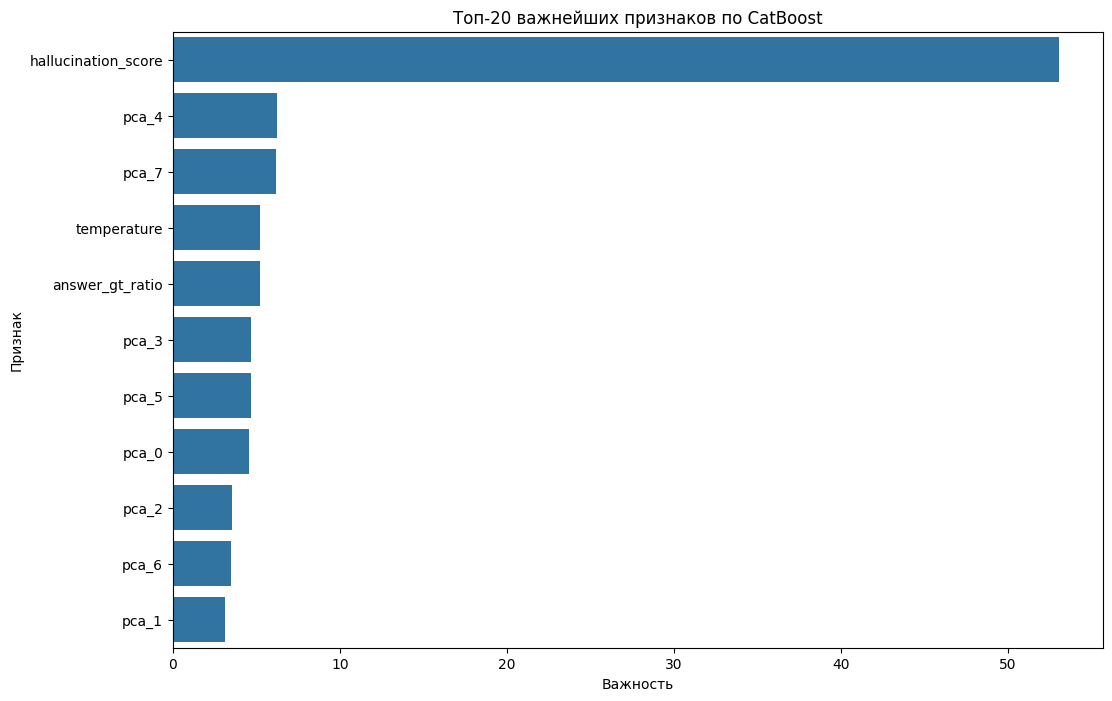

In [15]:
# best_model - catboost, feature importance
if best_model_type == "catboost":
    feature_importances = best_model.get_feature_importance()
    feature_names = X.columns
    importance_df = pd.DataFrame({"feature": feature_names, "importance": feature_importances})
    importance_df = importance_df.sort_values(by="importance", ascending=False)
    plt.figure(figsize=(12, 8))
    sns.barplot(x="importance", y="feature", data=importance_df.head(20))
    plt.title("Топ-20 важнейших признаков по CatBoost")
    plt.xlabel("Важность")
    plt.ylabel("Признак")
    plt.show()

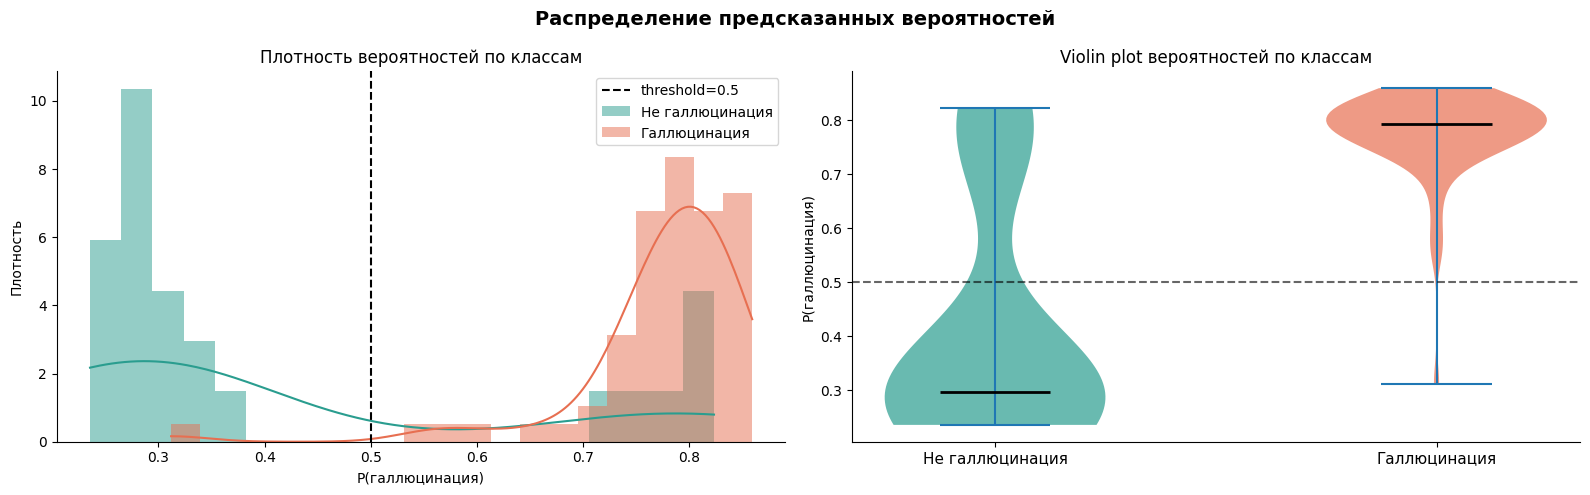

In [16]:
y_probs = best_model.predict_proba(X_test)[:, 1]

df_proba = pd.DataFrame({"proba": y_probs, "target": y_test.values})
colors = {0: "#2a9d8f", 1: "#e76f51"}
labels = {0: "Не галлюцинация", 1: "Галлюцинация"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Распределение предсказанных вероятностей", fontsize=14, fontweight="bold")

# гистограмма с KDE
for label in [0, 1]:
    subset = df_proba[df_proba["target"] == label]["proba"]
    sns.histplot(
        subset, bins=20, kde=True, ax=axes[0],
        color=colors[label], alpha=0.5, label=labels[label],
        stat="density", linewidth=0,
    )
    axes[0].lines[-1].set_color(colors[label])

axes[0].axvline(0.5, color="black", linestyle="--", lw=1.5, label="threshold=0.5")
axes[0].set_title("Плотность вероятностей по классам")
axes[0].set_xlabel("P(галлюцинация)")
axes[0].set_ylabel("Плотность")
axes[0].legend(fontsize=10)
sns.despine(ax=axes[0])

# violin plot
df_proba["Класс"] = df_proba["target"].map(labels)
parts = axes[1].violinplot(
    [df_proba[df_proba["target"] == 0]["proba"],
     df_proba[df_proba["target"] == 1]["proba"]],
    positions=[0, 1], showmedians=True, showextrema=True,
)
for i, (pc, color) in enumerate(zip(parts["bodies"], [colors[0], colors[1]])):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts["cmedians"].set_color("black")
parts["cmedians"].set_linewidth(2)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(list(labels.values()), fontsize=11)
axes[1].set_title("Violin plot вероятностей по классам")
axes[1].set_ylabel("P(галлюцинация)")
axes[1].axhline(0.5, color="black", linestyle="--", lw=1.5, alpha=0.6)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [17]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

test_df = features_df.iloc[X_test.index].copy()
test_df["pred_proba"] = y_probs
test_df["pred_label"] = (y_probs >= 0.5).astype(int)
test_df["error_type"] = "Верно"
test_df.loc[(test_df["pred_label"] == 1) & (test_df[target_col] == 0), "error_type"] = "FP"
test_df.loc[(test_df["pred_label"] == 0) & (test_df[target_col] == 1), "error_type"] = "FN"
errors_df = test_df[test_df["error_type"] != "Верно"]

logger.info(f"Ошибок: {len(errors_df)} из {len(test_df)} ({len(errors_df)/len(test_df)*100:.1f}%)")
logger.info(f"FP: {(test_df['error_type']=='FP').sum()} | FN: {(test_df['error_type']=='FN').sum()}")

color_map = {"Верно": "#2a9d8f", "FP": "#e76f51", "FN": "#f4a261"}

# ── 1a. Pie ──────────────────────────────────────────────────────
type_counts = test_df["error_type"].value_counts()
fig_pie = go.Figure(go.Pie(
    labels=type_counts.index.tolist(),
    values=type_counts.values.tolist(),
    marker_colors=[color_map[k] for k in type_counts.index],
    hole=0.35,
    textinfo="label+percent+value",
))
fig_pie.update_layout(title_text="Типы предсказаний", height=400)
fig_pie.show()

# ── 2. Scatter: pred_proba vs hallucination_score ──────────────────
if "hallucination_score" in test_df.columns:
    hover_cols = ["query", "ground_truth", "model_answer", "pred_proba", "error_type"]
    hover_cols = [c for c in hover_cols if c in test_df.columns]

    fig2 = px.scatter(
        test_df,
        x="hallucination_score",
        y="pred_proba",
        color="error_type",
        color_discrete_map=color_map,
        symbol="error_type",
        symbol_map={"Верно": "circle", "FP": "x", "FN": "triangle-up"},
        hover_data={c: True for c in hover_cols},
        title="pred_proba vs hallucination_score",
        labels={"hallucination_score": "hallucination_score (fuzz)", "pred_proba": "P(галлюцинация)"},
        opacity=0.75,
        height=520,
    )
    fig2.add_hline(y=0.5, line_dash="dash", line_color="black", opacity=0.5)
    fig2.update_traces(marker_size=9)
    fig2.update_layout(legend_title_text="Тип предсказания")
    fig2.show()

# ── 3. Box: hallucination_score по типам ──────────────────────────
if "hallucination_score" in test_df.columns:
    fig3 = px.box(
        test_df,
        x="error_type",
        y="hallucination_score",
        color="error_type",
        color_discrete_map=color_map,
        points="all",
        hover_data=["query", "model_answer", "pred_proba"],
        title="hallucination_score по типам предсказаний",
        labels={"error_type": "Тип", "hallucination_score": "hallucination_score"},
        height=480,
        category_orders={"error_type": ["Верно", "FP", "FN"]},
    )
    fig3.update_traces(jitter=0.3, marker_size=6)
    fig3.update_layout(showlegend=False)
    fig3.show()

# ── 4. Violin: pred_proba по классам ──────────────────────────────
fig4 = px.violin(
    test_df,
    x="error_type",
    y="pred_proba",
    color="error_type",
    color_discrete_map=color_map,
    box=True,
    points="all",
    hover_data=["query", "pred_proba"],
    title="Распределение pred_proba по типам",
    labels={"error_type": "Тип", "pred_proba": "P(галлюцинация)"},
    height=480,
    category_orders={"error_type": ["Верно", "FP", "FN"]},
)
fig4.add_hline(y=0.5, line_dash="dash", line_color="black", opacity=0.5)
fig4.update_layout(showlegend=False)
fig4.show()

# ── 5. Таблица топ ошибок ─────────────────────────────────────────
for etype, title, sort_asc in [
    ("FP", "🔴 False Positives — предсказал галлюцинацию, а её нет", False),
    ("FN", "🟠 False Negatives — пропустил галлюцинацию", True),
]:
    subset = errors_df[errors_df["error_type"] == etype].sort_values("pred_proba", ascending=sort_asc).head(5)
    if subset.empty:
        continue
    print(f"\n{'='*80}\n{title} (топ-5)\n{'='*80}")
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        score = f" | hallucination_score={row['hallucination_score']:.1f}" if "hallucination_score" in row else ""
        print(f"\n[{i}] proba={row['pred_proba']:.3f}{score}")
        print(f"  Q:  {str(row.get('query', ''))[:90]}")
        print(f"  GT: {str(row.get('ground_truth', ''))[:70]}")
        print(f"  MA: {str(row.get('model_answer', ''))[:70]}")

2026-03-31 13:12:24,134 - jupyter-notebooks - INFO - [JUPYTER 📓] Ошибок: 7 из 93 (7.5%)
2026-03-31 13:12:24,137 - jupyter-notebooks - INFO - [JUPYTER 📓] FP: 6 | FN: 1



🔴 False Positives — предсказал галлюцинацию, а её нет (топ-5)

[1] proba=0.824 | hallucination_score=-0.2
  Q:  Марк Абрахамс, который был редактором "Журнала невоспроизводимых результатов", в 1991 году
  GT: Игнобелевская премия {зачет: Шнобелевская премия}
  MA: Марк Абрахамс, редактор журнала «Анналы невероятных исследований», в 1

[2] proba=0.812 | hallucination_score=-0.3
  Q:  Именно для этого был выкопан Кильский канал.
  GT: Чтобы обеспечить проход больших кораблей, в первую очередь военных, из
  MA: Кильский канал — это искусственный водный путь в Германии, соединяющий

[3] proba=0.810 | hallucination_score=-0.7
  Q:  Как следует из сиквела, у НЕЕ было предубеждение против роботов, что неудивительно, ведь р
  GT: Сара Коннор (х/ф "Терминатор", "Терминатор-2")
  MA: Из контекста видно, что речь идет о персонаже, который испытывает непр

[4] proba=0.785 | hallucination_score=-0.5
  Q:  К ЭТОМУ РОДУ деревьев относится Гиперион, растущий в национальном парке в северной Калифор
  

In [20]:
from sklearn.metrics import average_precision_score

prauc = average_precision_score(y_test, y_probs)
logger.info(f"PR AUC: {prauc:.4f}")

2026-03-31 13:13:47,819 - jupyter-notebooks - INFO - [JUPYTER 📓] PR AUC: 0.9425


In [21]:
# save model
from common.paths import get_sber_public_checkpoints_dpath
import joblib
import datetime

ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
metric = prauc
fname = f"hallucination_model_{ts}_prauc_{metric:.4f}.joblib"
model_save_path = get_sber_public_checkpoints_dpath() / fname
joblib.dump(best_model, model_save_path)
logger.info(f"Модель сохранена: {model_save_path}")

2026-03-31 13:14:05,667 - jupyter-notebooks - INFO - [JUPYTER 📓] Модель сохранена: C:\Users\User\Desktop\dirs\Dev\hack-mfti\sber\public_checkpoints\hallucination_model_20260331_131405_prauc_0.9425.joblib
